# cProfile Visualization based on the results of declearn MNIST Quickrun

This notebook loads a `.prof` file produced by cProfile and visualizes the profiling data.

**Key metrics from cProfile:**
- **tottime** — time spent *inside* a function only, excluding sub-calls
- **cumtime** — time spent inside a function *including* all its sub-calls
- **ncalls** — how many times a function was called
- **percall** — tottime / ncalls
- **self_ratio** — tottime / cumtime — how much work a function does itself vs delegates

## 1. Setup

In [1]:
import pstats
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import numpy as np

## 2. Load profiling data

In [2]:
stats = pstats.Stats("output.prof")
print(f"Total CPU time: {stats.total_tt:.2f}s")

Total CPU time: 191.15s


## 3. Categorize functions by module

Each function is assigned a category based on its file path:
- declearn subpackages (model, optimizer, training, etc.)
- External libraries (tensorflow, numpy)
- Python builtins
- Other

In [3]:
def categorize(filepath):
    if "declearn/declearn/" in filepath:
        parts = filepath.split("declearn/declearn/")[1].split("/")
        if len(parts) > 1:
            return parts[0]
        return "declearn (other)"
    if "tensorflow" in filepath:
        return "tensorflow"
    if "numpy" in filepath:
        return "numpy"
    if filepath == "~":
        return "builtin"
    return "other"

## 4. Extract function data

Build a list of dictionaries, one per function, with all the metrics we care about.

In [4]:
functions = []
for (file, line, name), (cc, nc, tt, ct, callers) in stats.stats.items():
    if tt == 0:
        continue
    functions.append({
        "name": name,
        "file": file,
        "tottime": tt,
        "cumtime": ct,
        "ncalls": nc,
        "category": categorize(file),
        "self_ratio": tt / ct if ct > 0 else 0,
        "percall": tt / nc if nc > 0 else 0,
    })

print(f"Extracted {len(functions)} functions with non-zero tottime")

Extracted 17664 functions with non-zero tottime


## 5. Time breakdown by category

Shows how much CPU time (tottime) each category accounts for.
(what percentage of total time is within declearn's control?)

In [5]:
cat_time = defaultdict(float)
for f in functions:
    cat_time[f["category"]] += f["tottime"]

for cat, t in sorted(cat_time.items(), key=lambda x: x[1], reverse=True):
    pct = t / stats.total_tt * 100
    print(f"{cat:25s}  {t:8.2f}s  ({pct:.1f}%)")

builtin                      108.14s  (56.6%)
tensorflow                    55.42s  (29.0%)
other                         15.22s  (8.0%)
model                          9.67s  (5.1%)
optimizer                      1.26s  (0.7%)
dataset                        0.70s  (0.4%)
training                       0.34s  (0.2%)
numpy                          0.28s  (0.1%)
metrics                        0.04s  (0.0%)
main                           0.02s  (0.0%)
utils                          0.02s  (0.0%)
communication                  0.02s  (0.0%)
messaging                      0.02s  (0.0%)
quickrun                       0.00s  (0.0%)
fairness                       0.00s  (0.0%)
secagg                         0.00s  (0.0%)
aggregator                     0.00s  (0.0%)
client_sampler                 0.00s  (0.0%)
test_utils                     0.00s  (0.0%)
data_info                      0.00s  (0.0%)
declearn (other)               0.00s  (0.0%)


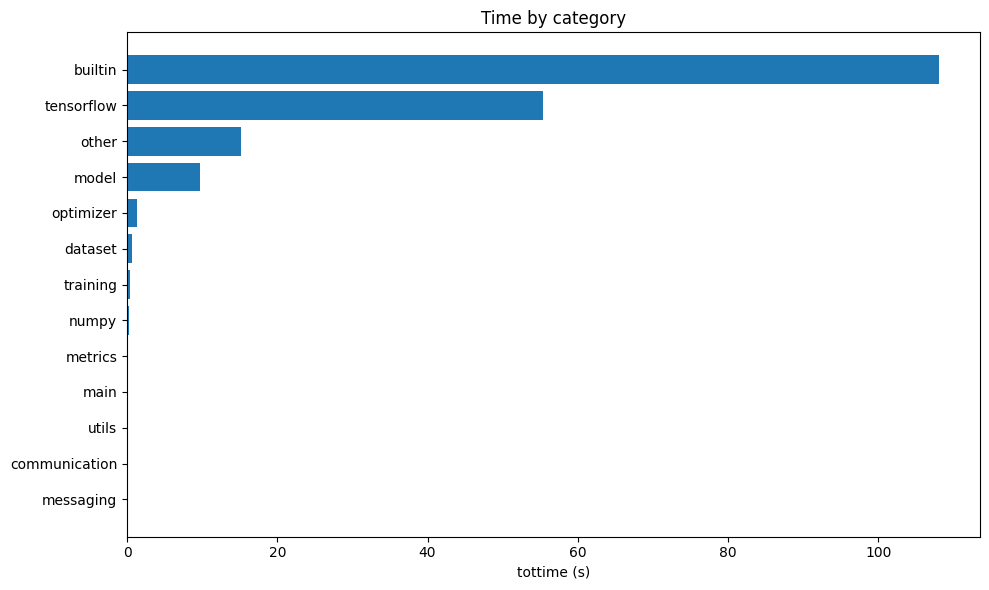

In [6]:
cat_sorted = sorted(cat_time.items(), key=lambda x: x[1], reverse=True)
cat_sorted = [(c, t) for c, t in cat_sorted if t > 0.01]

labels = [c for c, t in cat_sorted]
times = [t for c, t in cat_sorted]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels[::-1], times[::-1])
ax.set_xlabel("tottime (s)")
ax.set_title("Time by category")
plt.tight_layout()
plt.savefig("profile_categories.png", dpi=150)

## 6. Declearn functions by cumtime


In [7]:
declearn_cats = ["model", "optimizer", "dataset", "training", "metrics",
                 "main", "utils", "communication", "messaging"]

dl_funcs = [f for f in functions if f["category"] in declearn_cats]

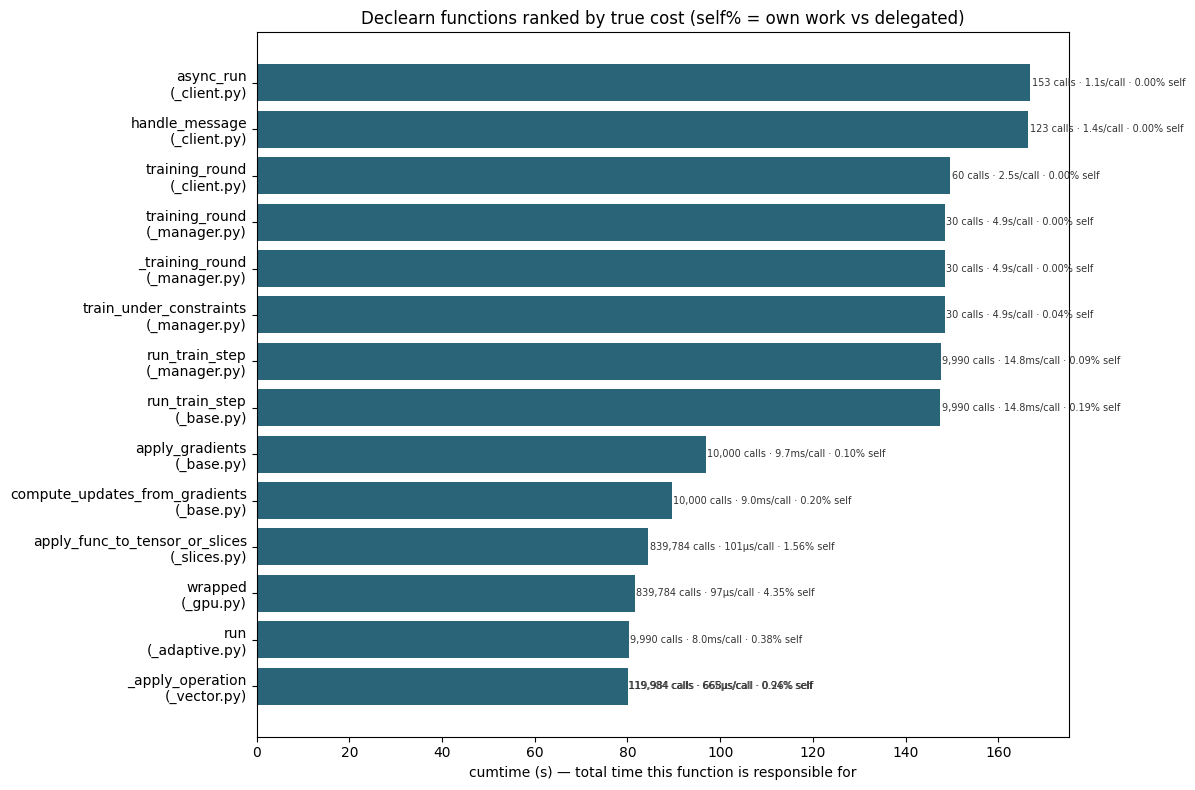

: 

In [ ]:
dl_funcs.sort(key=lambda x: x["cumtime"], reverse=True)
dl_top = dl_funcs[:15]
dl_top.reverse()

labels = [f"{f['name']}\n({os.path.basename(f['file'])})" for f in dl_top]
cumtimes = [f["cumtime"] for f in dl_top]
ncalls = [f["ncalls"] for f in dl_top]
ratios = [f["self_ratio"] for f in dl_top]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels, cumtimes, color="#2a6478")

for i, (bar, nc, ratio) in enumerate(zip(bars, ncalls, ratios)):
    w = bar.get_width()
    f = dl_top[i]
    pc = f["cumtime"] / nc if nc > 0 else 0

    if pc >= 1:
        pc_str = f"{pc:.1f}s/call"
    elif pc >= 0.001:
        pc_str = f"{pc*1000:.1f}ms/call"
    else:
        pc_str = f"{pc*1e6:.0f}µs/call"

    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f"{nc:,} calls · {pc_str} · {ratio:.2%} self",
            va='center', fontsize=7, color='#333')

ax.set_xlabel("cumtime (s) — total time this function is responsible for")
ax.set_title("Declearn functions ranked by true cost (self% = own work vs delegated)")
plt.tight_layout()
plt.savefig("cumtime_with_ratio.png", dpi=150)